In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
from pyscf import gto, scf, fci
import netket.experimental as nkx
import expect_grad_ex
import vmc_ex
import jax
from functools import reduce

# 设置H2分子的几何构型
bond_length = 1.4  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
cisolver.nroots=3
E_fcis, fcivec = cisolver.kernel()
print(f"FCI基态能量: {E_fcis[0]:.8f} Ha")

print(f"\nFCI所有能级:")
for i, e in enumerate(E_fcis):
    print(f"  E{i} = {e:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/utils/dispatch.py:25: FutureWarning: 
The variables `nk.utils.dispatch.{TrueT|FalseT|Bool}` are deprecated. Their usages
should instead be replaced by the following objects:

    `TrueT` should be replaced by `typing.Literal[True]`
    `FalseT` should be replaced by `typing.Literal[False]`
    `Bool` should be replaced by `bool`

  _warn_deprecation(
/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/driver/vmc_common.py:33: FutureWarning: 

            `nk.driver.vmc_common is deprecated and the functionality removed.   

If you imported `nk.driver.vmc_common`, you must reimplement that functionality yourself.


  warn_deprecation(


Hartree-Fock能量: -0.94148065 Ha
FCI基态能量: -1.01546825 Ha

FCI所有能级:
  E0 = -1.01546825 Ha
  E1 = -0.87542794 Ha
  E2 = -0.42938376 Ha


In [2]:
# 创建Hilbert空间
# H2分子在STO-3G基组下有2个空间轨道，每个轨道有自旋向上和向下
# 总共4个自旋轨道，编号为0,1,2,3
# 其中0,2是自旋向上，1,3是自旋向下
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 2个空间轨道
    s=1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋1个电子
)

In [3]:
# 创建采样器 - 使用费米子跳跃采样器
# 图结构定义了允许的电子跳跃
# 对于H2分子，我们允许所有可能的跳跃
#g = nk.graph.Graph(edges=[(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)])
g = nk.graph.Graph(edges=[(0,1),(2,3)])
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

print(f"采样器图边数: {g.n_edges}")

采样器图边数: 2


In [4]:
# 创建变分量子态 - 使用RBM作为神经网络
ma = nk.models.RBM(alpha=2, param_dtype=complex, use_visible_bias=False)
vs = nk.vqs.MCState(sa, ma, n_discard_per_chain=100, n_samples=1024)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.1)
sr = nk.optimizer.SR(diag_shift=0.01, holomorphic=True)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行基态优化
exp_name = "h2_ground_state"
gs.run(out=exp_name, n_iter=300)

# 获取基态能量
data = json.load(open(exp_name + '.log'))
energy_gs = data["Energy"]["Mean"]["real"]
final_energy_gs = reduce(lambda x, y: x if y is None else y, energy_gs)
print(f"\n基态能量: {final_energy_gs:.8f} Ha")
print(f"与FCI误差: {abs(final_energy_gs - E_fcis[0]):.8f} Ha")

100%|██████████| 300/300 [00:38<00:00,  7.71it/s, Energy=-1.015e+00+1.071e-09j ± 2.308e-09 [σ²=2.727e-15, R̂=1.3938]]    


基态能量: -1.01546825 Ha
与FCI误差: 0.00000000 Ha


In [5]:
# 保存基态参数
gs_params = vs.parameters
with open('Data/RBM/v0.json', 'wb') as f:
    pickle.dump(gs_params, f)
print("基态参数已保存到 Data/RBM/v0.json")


基态参数已保存到 Data/RBM/v0.json


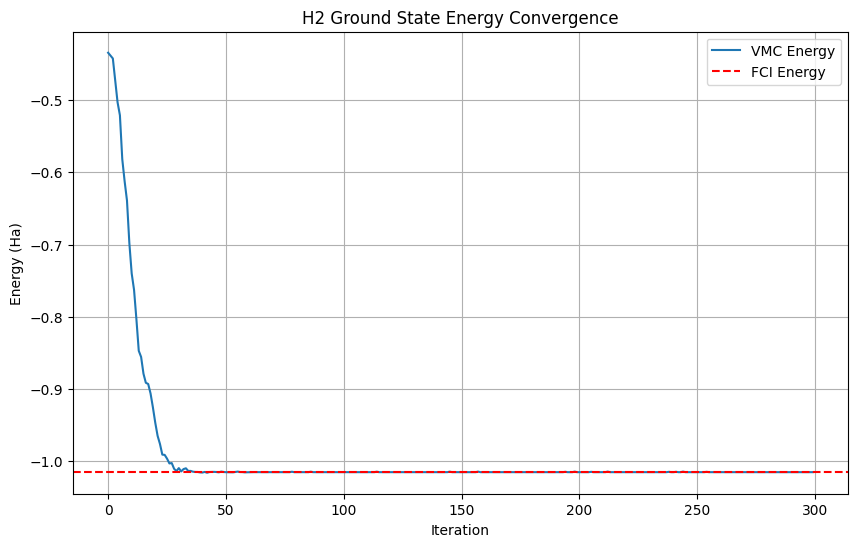

In [6]:
# 绘制基态能量收敛曲线
data = json.load(open('h2_ground_state' + '.log'))
iters = data["Energy"]["iters"]
energy = data["Energy"]["Mean"]["real"]
E_fci = E_fcis[0]
plt.figure(figsize=(10, 6))
plt.plot(iters, energy, label='VMC Energy')
plt.axhline(y=E_fci, color='r', linestyle='--', label='FCI Energy')
plt.xlabel('Iteration')
plt.ylabel('Energy (Ha)')
plt.title('H2 Ground State Energy Convergence')
plt.legend()
plt.grid(True)
plt.show()

## 第一激发态计算

现在使用激发态VMC方法计算第一激发态。需要传入基态作为正交化约束。

In [7]:
# 加载基态参数
ma = nk.models.RBM(alpha=2, param_dtype=complex, use_visible_bias=False)
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

with open('Data/RBM/v0.json', 'rb') as f:
    gs_params = pickle.load(f)

# 创建基态变分态对象
vs_gs = nk.vqs.MCState(sampler, ma, n_discard_per_chain=100, n_samples=1024)
vs_gs.init_parameters(jax.nn.initializers.normal(stddev=0.25))
vs_gs.parameters = gs_params

print("基态参数已加载")

基态参数已加载


In [8]:
# 设置第一激发态计算
# 创建新的变分态用于第一激发态
ma_ex1 = nk.models.RBM(alpha=2, param_dtype=complex, use_visible_bias=False)
vs_ex1 = nk.vqs.MCState(sampler, ma_ex1, n_discard_per_chain=100, n_samples=1024)

# 设置优化器
opt_ex1 = nk.optimizer.Sgd(learning_rate=0.1)
sr_ex1 = nk.optimizer.SR(diag_shift=0.01, holomorphic=True)

# 设置能量位移参数（用于正交化约束）
# 位移参数应该足够大以确保正交化
shift_list = [2.0]  # 基态的位移参数
state_list = [vs_gs]  # 基态列表

# 创建激发态VMC驱动器
gs_ex1 = vmc_ex.VMC_ex(
    hamiltonian=ha,
    optimizer=opt_ex1,
    variational_state=vs_ex1,
    preconditioner=sr_ex1,
    state_list=state_list,
    shift_list=shift_list
)

# 运行第一激发态优化
exp_name_ex1 = "h2_excited_state_1"
gs_ex1.run(out=exp_name_ex1, n_iter=500)

# 获取第一激发态能量
data_ex1 = json.load(open(exp_name_ex1 + '.log'))
energy_ex1 = data_ex1["Energy"]["Mean"]["real"]
final_energy_ex1 = reduce(lambda x, y: x if y is None else y, energy_ex1)


100%|██████████| 500/500 [02:23<00:00,  3.48it/s, Energy=-8.754e-01+2.466e-06j ± 4.163e-17 [σ²=5.142e-09, R̂=0.9682]]    


In [9]:
print(f"\n第一激发态能量: {final_energy_ex1:.8f} Ha| 精确解: {E_fcis[1]:.8f} Ha")
print(f"激发能: {final_energy_ex1 - final_energy_gs:.8f} Ha")
print(f"与FCI第一激发态误差: {abs(final_energy_ex1 - E_fcis[1]):.8f} Ha")


第一激发态能量: -0.87543047 Ha| 精确解: -0.87542794 Ha
激发能: 0.14003778 Ha
与FCI第一激发态误差: 0.00000253 Ha


In [10]:
# 保存第一激发态参数
ex1_params = vs_ex1.parameters
with open('Data/RBM/v1.json', 'wb') as f:
    pickle.dump(ex1_params, f)
print("第一激发态参数已保存到 Data/RBM/v1.json")


第一激发态参数已保存到 Data/RBM/v1.json


In [11]:
# 绘制第一激发态能量收敛曲线
data_ex1 = json.load(open(exp_name_ex1 + '.log'))
iters_ex1 = data_ex1["Energy"]["iters"]
energy_ex1_plot = data_ex1["Energy"]["Mean"]["real"]


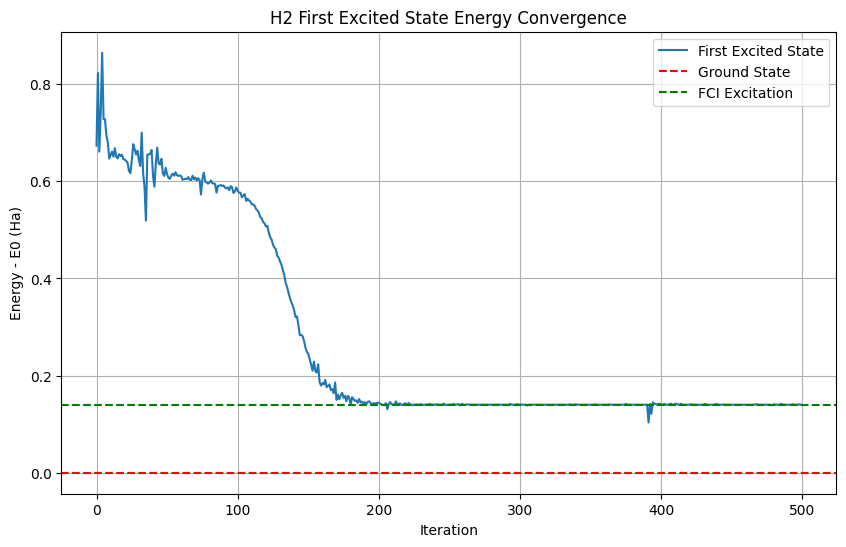

In [12]:
plt.figure(figsize=(10, 6))
ex1_error = [i-E_fcis[0] for i in energy_ex1_plot]

plt.plot(iters_ex1, ex1_error, label='First Excited State')
plt.axhline(y=0, color='r', linestyle='--', label='Ground State')
plt.axhline(y=E_fcis[1] - E_fci, color='g', linestyle='--', label='FCI Excitation')
plt.xlabel('Iteration')
plt.ylabel('Energy - E0 (Ha)')
plt.title('H2 First Excited State Energy Convergence')
plt.legend()
plt.grid(True)
plt.show()

## 第二激发态计算

使用基态和第一激发态作为正交化约束来计算第二激发态。

In [13]:
# 加载第一激发态参数
with open('Data/v1.json', 'rb') as f:
    ex1_params = pickle.load(f)

# 创建第一激发态变分态对象
vs_ex1_loaded = nk.vqs.MCState(sampler, ma, n_discard_per_chain=100, n_samples=1024)
vs_ex1_loaded.init_parameters(jax.nn.initializers.normal(stddev=0.25))
vs_ex1_loaded.parameters = ex1_params

print("第一激发态参数已加载")

第一激发态参数已加载


In [20]:
# 设置第二激发态计算
# 创建新的变分态用于第二激发态
ma_ex2 = nk.models.RBM(alpha=2, param_dtype=complex, use_visible_bias=False)
vs_ex2 = nk.vqs.MCState(sampler, ma_ex2, n_discard_per_chain=100, n_samples=1024)

# 设置优化器
opt_ex2 = nk.optimizer.Sgd(learning_rate=0.1)
sr_ex2 = nk.optimizer.SR(diag_shift=0.01, holomorphic=True)

# 设置能量位移参数和状态列表
# 使用较大的位移参数确保正交化
shift_list_ex2 = [2.0, 4.0]  # 基态和第一激发态的位移参数
state_list_ex2 = [vs_gs, vs_ex1_loaded]  # 基态和第一激发态列表

# 创建激发态VMC驱动器
gs_ex2 = vmc_ex.VMC_ex(
    hamiltonian=ha,
    optimizer=opt_ex2,
    variational_state=vs_ex2,
    preconditioner=sr_ex2,
    state_list=state_list_ex2,
    shift_list=shift_list_ex2
)


# 运行第二激发态优化
exp_name_ex2 = "h2_excited_state_2"
gs_ex2.run(out=exp_name_ex2, n_iter=500)

# 获取第二激发态能量
data_ex2 = json.load(open(exp_name_ex2 + '.log'))
energy_ex2 = data_ex2["Energy"]["Mean"]["real"]
final_energy_ex2 = reduce(lambda x, y: x if y is None else y, energy_ex2)
print(f"\n第二激发态能量: {final_energy_ex2:.8f} Ha")
print(f"激发能: {final_energy_ex2 - final_energy_gs:.8f} Ha")
print(f"与FCI第二激发态误差: {abs(final_energy_ex2 - E_fcis[2]):.8f} Ha")

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [03:09<00:00,  2.64it/s, Energy=-0.87184-0.00053j ± 0.00091 [σ²=0.00089, R̂=1.0285]]


第二激发态能量: -0.87183974 Ha
激发能: 0.14362851 Ha
与FCI第二激发态误差: 0.44245598 Ha


In [17]:
print(f"\n第二激发态能量: {final_energy_ex2:.8f} Ha|精确解: {E_fcis[2]:.8f} Ha")
print(f"激发能: {final_energy_ex2 - final_energy_gs:.8f} Ha")
print(f"与FCI第二激发态误差: {abs(final_energy_ex2 - E_fcis[2]):.8f} Ha")


第二激发态能量: -0.86271157 Ha|精确解: -0.42938376 Ha
激发能: 0.15275668 Ha
与FCI第二激发态误差: 0.43332781 Ha


In [22]:
# 保存第二激发态参数
ex2_params = vs_ex2.parameters
with open('Data/v2.json', 'wb') as f:
    pickle.dump(ex2_params, f)
print("第二激发态参数已保存到 Data/v2.json")

第二激发态参数已保存到 Data/v2.json


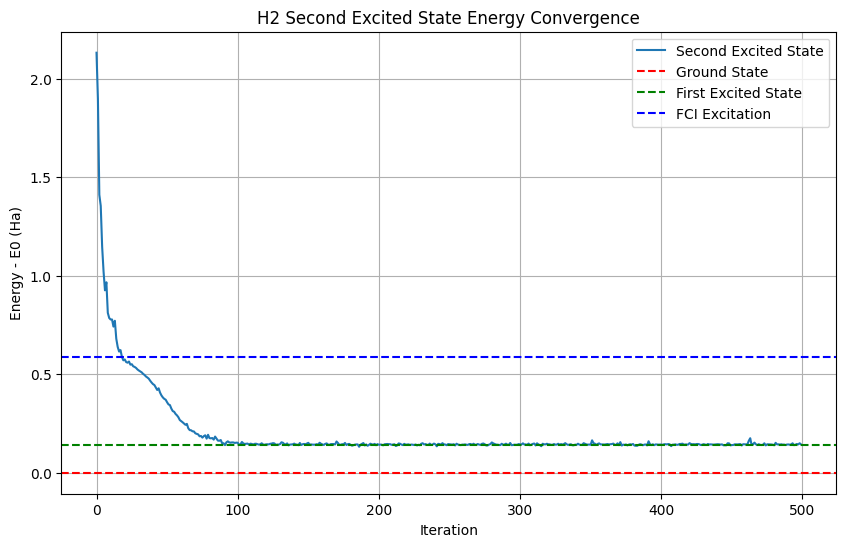

In [23]:
# 绘制第二激发态能量收敛曲线
data_ex2 = json.load(open(exp_name_ex2 + '.log'))
iters_ex2 = data_ex2["Energy"]["iters"]
energy_ex2_plot = data_ex2["Energy"]["Mean"]["real"]

plt.figure(figsize=(10, 6))
plt.plot(iters_ex2, [i-final_energy_gs for i in energy_ex2_plot], label='Second Excited State')
plt.axhline(y=0, color='r', linestyle='--', label='Ground State')
plt.axhline(y=final_energy_ex1 - final_energy_gs, color='g', linestyle='--', label='First Excited State')
plt.axhline(y=E_fcis[2] - E_fci, color='b', linestyle='--', label='FCI Excitation')
plt.xlabel('Iteration')
plt.ylabel('Energy - E0 (Ha)')
plt.title('H2 Second Excited State Energy Convergence')
plt.legend()
plt.grid(True)
plt.show()

## 结果总结

比较所有计算得到的能级。

In [25]:
# 打印所有能级总结
print("="*60)
print("H2 分子能级总结")
print("="*60)
e_fci_all = E_fcis
print(f"基态能量 (E0): {final_energy_gs:.8f} Ha")
print(f"第一激发态能量 (E1): {final_energy_ex1:.8f} Ha")
print(f"第二激发态能量 (E2): {final_energy_ex2:.8f} Ha")
print(f"\n第一激发能 (E1-E0): {final_energy_ex1 - final_energy_gs:.8f} Ha")
print(f"第二激发能 (E2-E0): {final_energy_ex2 - final_energy_gs:.8f} Ha")
print(f"\nFCI基态能量: {E_fci:.8f} Ha")
print(f"FCI第一激发态能量: {e_fci_all[1]:.8f} Ha")
print(f"FCI第二激发态能量: {e_fci_all[2]:.8f} Ha")
print(f"\n基态误差: {abs(final_energy_gs - E_fci):.8f} Ha")
print(f"第一激发态误差: {abs(final_energy_ex1 - e_fci_all[1]):.8f} Ha")
print(f"第二激发态误差: {abs(final_energy_ex2 - e_fci_all[2]):.8f} Ha")

H2 分子能级总结
基态能量 (E0): -1.01546825 Ha
第一激发态能量 (E1): -0.87543047 Ha
第二激发态能量 (E2): -0.87183974 Ha

第一激发能 (E1-E0): 0.14003778 Ha
第二激发能 (E2-E0): 0.14362851 Ha

FCI基态能量: -1.01546825 Ha
FCI第一激发态能量: -0.87542794 Ha
FCI第二激发态能量: -0.42938376 Ha

基态误差: 0.00000000 Ha
第一激发态误差: 0.00000253 Ha
第二激发态误差: 0.44245598 Ha


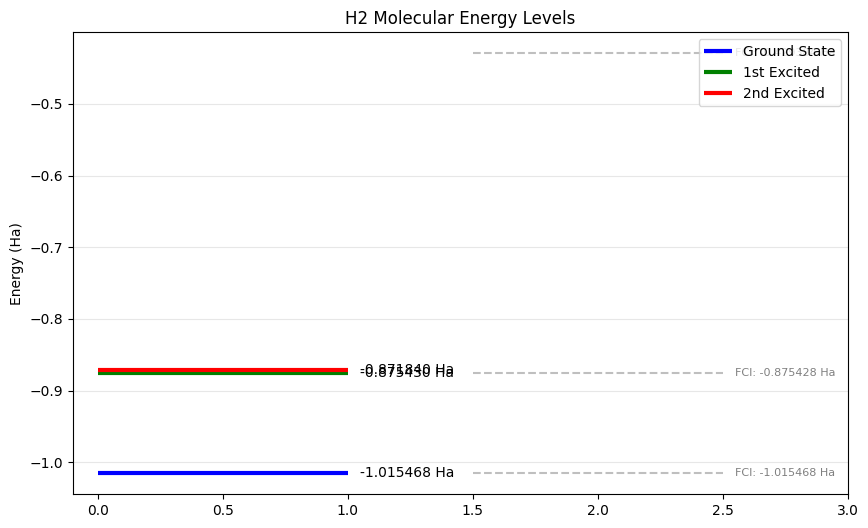

In [26]:
# 绘制能级图
energies = [final_energy_gs, final_energy_ex1, final_energy_ex2]
labels = ['Ground State', '1st Excited', '2nd Excited']
colors = ['blue', 'green', 'red']

plt.figure(figsize=(10, 6))
for i, (E, label, color) in enumerate(zip(energies, labels, colors)):
    plt.hlines(E, 0, 1, colors=color, linewidth=3, label=label)
    plt.text(1.05, E, f'{E:.6f} Ha', va='center', fontsize=10)

# 添加FCI参考线
for i, E_fci in enumerate(e_fci_all[:3]):
    plt.hlines(E_fci, 1.5, 2.5, colors='gray', linestyle='--', alpha=0.5)
    plt.text(2.55, E_fci, f'FCI: {E_fci:.6f} Ha', va='center', fontsize=8, color='gray')

plt.xlim(-0.1, 3)
plt.ylabel('Energy (Ha)')
plt.title('H2 Molecular Energy Levels')
plt.legend(loc='upper right')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

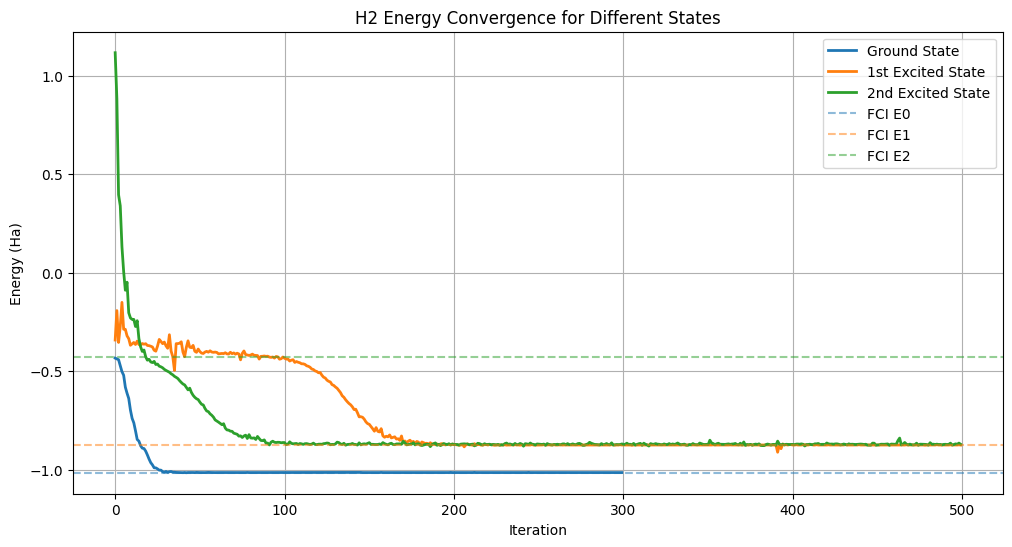

In [27]:
# 绘制所有状态的收敛曲线比较
plt.figure(figsize=(12, 6))

# 基态
data_gs = json.load(open(exp_name + '.log'))
iters_gs = data_gs["Energy"]["iters"]
energy_gs_plot = data_gs["Energy"]["Mean"]["real"]
plt.plot(iters_gs, energy_gs_plot, label='Ground State', linewidth=2)

# 第一激发态
data_ex1 = json.load(open(exp_name_ex1 + '.log'))
iters_ex1 = data_ex1["Energy"]["iters"]
energy_ex1_plot = data_ex1["Energy"]["Mean"]["real"]
plt.plot(iters_ex1, energy_ex1_plot, label='1st Excited State', linewidth=2)

# 第二激发态
data_ex2 = json.load(open(exp_name_ex2 + '.log'))
iters_ex2 = data_ex2["Energy"]["iters"]
energy_ex2_plot = data_ex2["Energy"]["Mean"]["real"]
plt.plot(iters_ex2, energy_ex2_plot, label='2nd Excited State', linewidth=2)

# 添加FCI参考线
for i, E_fci in enumerate(e_fci_all[:3]):
    plt.axhline(y=E_fci, color=f'C{i}', linestyle='--', alpha=0.5, label=f'FCI E{i}')

plt.xlabel('Iteration')
plt.ylabel('Energy (Ha)')
plt.title('H2 Energy Convergence for Different States')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# 检查态之间的正交性
def compute_overlap(vs1, vs2, n_samples=1000):
    """计算两个变分态之间的重叠"""
    samples1 = vs1.samples
    samples2 = vs2.samples
    
    # 计算波函数值
    psi1 = vs1.log_prob(samples1)
    psi2 = vs2.log_prob(samples1)
    
    # 计算重叠
    overlap = np.mean(np.exp(psi2 - psi1))
    return overlap

print("\n态之间的重叠检查:")
print("="*40)

# 重新加载所有状态
with open('Data/v0.json', 'rb') as f:
    gs_params = pickle.load(f)
with open('Data/v1.json', 'rb') as f:
    ex1_params = pickle.load(f)
with open('Data/v2.json', 'rb') as f:
    ex2_params = pickle.load(f)

vs_gs_check = nk.vqs.MCState(sampler, ma, n_discard_per_chain=100, n_samples=1024)
vs_gs_check.init_parameters(jax.nn.initializers.normal(stddev=0.25))
vs_gs_check.parameters = gs_params

vs_ex1_check = nk.vqs.MCState(sampler, ma, n_discard_per_chain=100, n_samples=1024)
vs_ex1_check.init_parameters(jax.nn.initializers.normal(stddev=0.25))
vs_ex1_check.parameters = ex1_params

vs_ex2_check = nk.vqs.MCState(sampler, ma, n_discard_per_chain=100, n_samples=1024)
vs_ex2_check.init_parameters(jax.nn.initializers.normal(stddev=0.25))
vs_ex2_check.parameters = ex2_params

# 计算重叠
overlap_gs_ex1 = compute_overlap(vs_gs_check, vs_ex1_check)
overlap_gs_ex2 = compute_overlap(vs_gs_check, vs_ex2_check)
overlap_ex1_ex2 = compute_overlap(vs_ex1_check, vs_ex2_check)

print(f"|<ψ_gs|ψ_ex1>|^2 = {abs(overlap_gs_ex1)**2:.6f}")
print(f"|<ψ_gs|ψ_ex2>|^2 = {abs(overlap_gs_ex2)**2:.6f}")
print(f"|<ψ_ex1|ψ_ex2>|^2 = {abs(overlap_ex1_ex2)**2:.6f}")
print("\n理想情况下，不同激发态之间的重叠应该接近0")


态之间的重叠检查:


AttributeError: 'MCState' object has no attribute 'log_prob'